## Convolutional Neural Networks in Pytorch

In [7]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        
        Y = []
        x = self.conv1(x)
        x = F.tanh(x)
        x = self.conv2(x)
        x = F.tanh(x)
        
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.tanh(x)
        
        x = self.dropout2(x)
        x = self.fc2(x)
        
        # torch.nn.CrossEntropyLoss includes the LogSoftmax activation function
        # while torch.nn.NLLLoss expects the input to be log-probabilities
        #output = F.log_softmax(x, dim=1)
        
        return x


def train(args, model, device, train_loader, optimizer, epoch):
    
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        
        #loss = F.nll_loss(output, target)
        loss = F.cross_entropy(output, target)
        
        loss.backward()
        optimizer.step()
        if batch_idx % args['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args['dry_run']:
                break


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss = F.cross_entropy(output, target, reduction='sum').item()
            #test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))


def main():
    
    args = {'lr':0.001, 
            'gamma':0.01,
            'epochs': 2, 
            'save_model': True, 
            'log_interval':10,
            'dry_run':False}
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_kwargs = {'batch_size': 64}
    test_kwargs = {'batch_size': 1000}
    
    accel_kwargs = {'num_workers': 1,
                    'persistent_workers': True,
                     'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(accel_kwargs)
    test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)

    print('#'*30)
    print(f'train size = {dataset1.data.shape}')
    print(f'test size = {dataset2.data.shape}')
    print('#'*30)
    
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=args['lr'])

    scheduler = StepLR(optimizer, step_size=1, gamma=args['gamma'])
    
    for epoch in range(1, args['epochs'] + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args['save_model']:
        torch.save(model.state_dict(), "mnist_cnn.pt")

    return model


if __name__ == '__main__':
    model = main()

Using device: cpu
##############################
train size = torch.Size([60000, 28, 28])
test size = torch.Size([10000, 28, 28])
##############################
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.311428
Train Epoch: 1 [640/60000 (1%)]	Loss: 0.842302
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.579337
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.452557
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.489195
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.459511
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.370440
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.427278
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.344596
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.278664
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.260844
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.497851
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.249267
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.302684
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.285019
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.182832
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.273713
Train Epoch: 1 [10

In [13]:
Ws = list(model.parameters())
len(Ws)

8

In [14]:
[W.shape for W in Ws]

[torch.Size([32, 1, 3, 3]),
 torch.Size([32]),
 torch.Size([64, 32, 3, 3]),
 torch.Size([64]),
 torch.Size([128, 9216]),
 torch.Size([128]),
 torch.Size([10, 128]),
 torch.Size([10])]

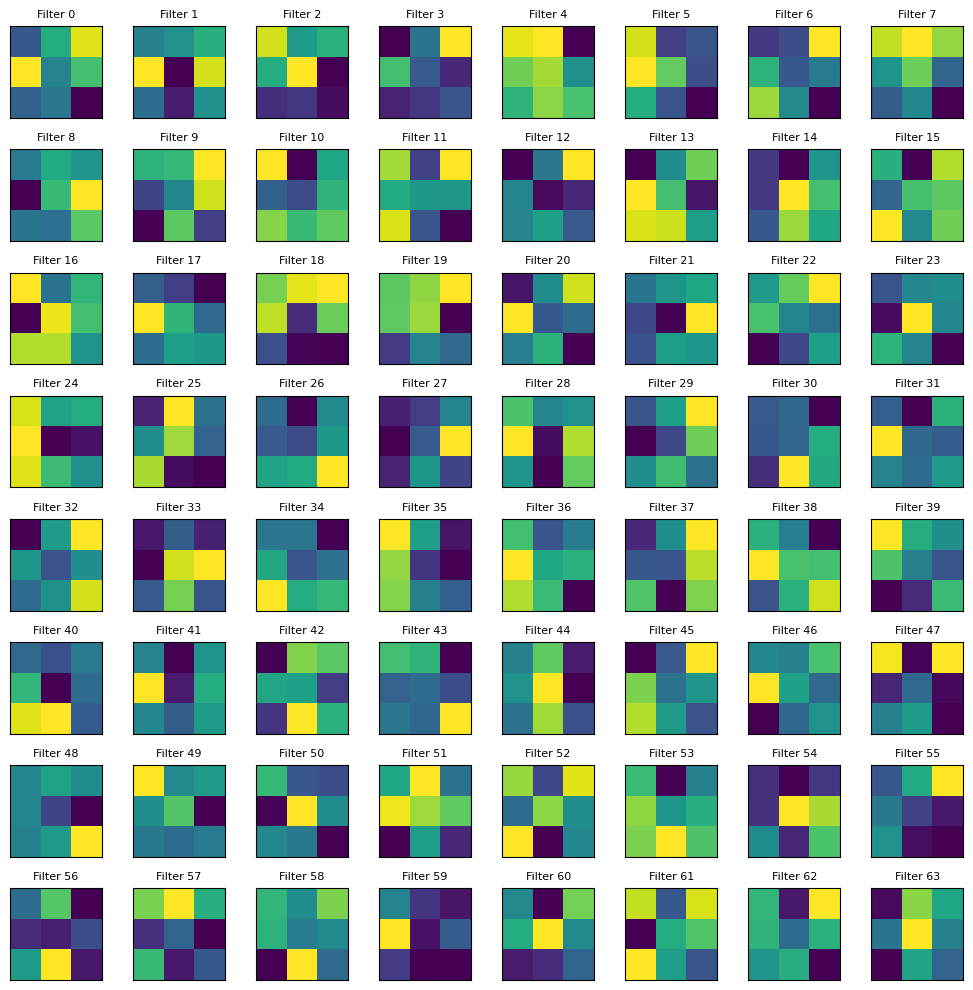

In [15]:
import matplotlib.pyplot as plt

weights = Ws[2].detach().cpu()  # shape: (64, 32, 3, 3)

kernels = weights.abs().mean(dim=1)  # shape: (64, 3, 3)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    ax.imshow(kernels[idx].numpy(), cmap="viridis", interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Filter {idx}", fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
test_loader = torch.utils.data.DataLoader(dataset2,batch_size = 1)

x = next(iter(test_loader))
print(f'X length:{len(x)}')
print(f'image size: {x[0].shape}')
print(f'Class label: {x[1]}')

X length:2
image size: torch.Size([1, 1, 28, 28])
Class label: tensor([7])


In [21]:
test_loader = torch.utils.data.DataLoader(dataset2,batch_size = 10,shuffle=False)

x = next(iter(test_loader))
print(f'X length:{len(x)}')
print(f'image size: {x[0].shape}')
print(f'Class label: {x[1]}')

X length:2
image size: torch.Size([10, 1, 28, 28])
Class label: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


torch.Size([10, 10])


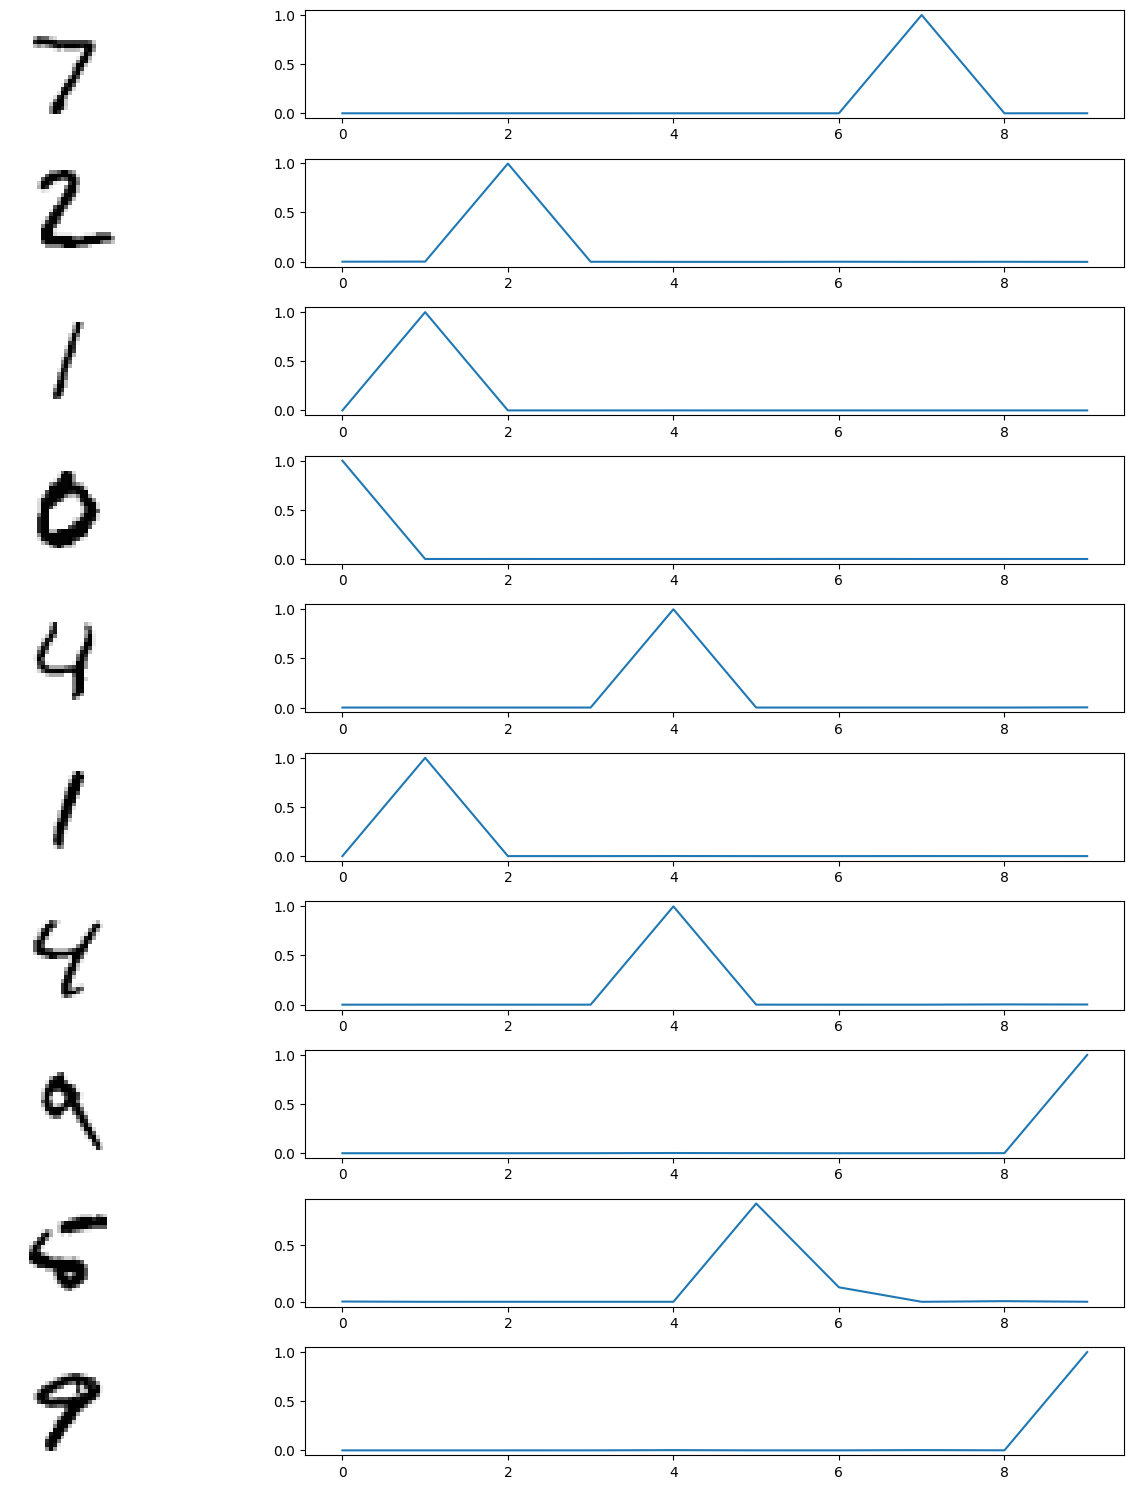

In [24]:
with torch.no_grad():
    output = model(x[0])
    pred = output.argmax(dim=1, keepdim=True)
    #print(f'output {output}')


print(output.shape)

prob = F.softmax(output, dim=1)


plt.figure(figsize=(15, 15))
ploti = 0
for i in range(10):
    ploti += 1
    plt.subplot(10, 2, ploti)
    plt.imshow(-x[0][i, 0, :, :], cmap='gray')
    plt.axis('off')
    ploti += 1
    plt.subplot(10, 2, ploti)
    Yprobs = prob[i, :]
    plt.plot(Yprobs)
plt.tight_layout()